In [2]:
import cv2
import matplotlib.pyplot as plt
import os
import random
import numpy as np
import pandas as pd
from glob import glob
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision.models import densenet121
import torchvision.models as models
from torch import Tensor

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, train_test_split


class CFG:
    DATASET_PATH = "/kaggle/input/prdb-rice/Original_Images"
    SEARCH_ROOTS = [DATASET_PATH, "/kaggle/input"]
    IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp")
    IMG_SIZE = 299
    SEED = 42
    NUM_WORKERS = 2
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SSL_BATCH = 64
    SSL_EPOCHS = 150
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    LP_BATCH = 32
    LP_EPOCHS = 30
    LP_LR = 1e-3
    USE_FOCAL = False
    VAL_SIZE = 0.2
    TEST_SIZE = 0.1
    ROI_CROP_PROB = 0.0
    INTENSITY_GAIN_RANGE = (0.8, 1.2)
    INTENSITY_BIAS_RANGE = (-15, 15)
    BG_ERASE_PROB = 0.4
    BG_ERASE_RATE = 0.1
    OUT_DIR = "/kaggle/working/prdb_ssl"
    
    SSL_CKPT_INCEPTION = "ssl_backbone_inception.pth"
    LP_CKPT_INCEPTION = "lp_classifier_inception.pth"
    

os.makedirs(CFG.OUT_DIR, exist_ok=True)

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed()


In [3]:
# 1. Class Map for PRDB
CLASS_MAP = {
    "Aush": 0,
    "Beroi": 1,
    "BR-28": 2,
    "BR-29": 3,
    "Chinigura": 4,
    "Ghee Bhog": 5,
    "Katari Najir": 6,
    "Katari Siddho": 7,
    "Miniket": 8,
    "Swarna":9
}
INV_CLASS = {v: k for k, v in CLASS_MAP.items()}

PRDB_ROOT = "/kaggle/input/prdb-rice/Original_Images"

assert os.path.exists(PRDB_ROOT), "ERROR: PRDB dataset path does NOT exist!"
print("[INFO] Using PRDB root:", PRDB_ROOT)


# 2. Build Image Index
def build_index(root=PRDB_ROOT):
    rows = []
    for cls, lbl in CLASS_MAP.items():
        cls_folder = os.path.join(root, cls)
        for img_path in glob(os.path.join(cls_folder, "*")):
            if not img_path.lower().endswith(CFG.IMG_EXTS):
                continue
            rows.append({"image": img_path, "label": lbl, "cls": cls})
    df = pd.DataFrame(rows)
    print("Counts per class:\n", df["cls"].value_counts())
    return df

df_all = build_index(PRDB_ROOT)


[INFO] Using PRDB root: /kaggle/input/prdb-rice/Original_Images
Counts per class:
 cls
Aush             200
Beroi            200
BR-28            200
BR-29            200
Chinigura        200
Ghee Bhog        200
Katari Najir     200
Katari Siddho    200
Miniket          200
Swarna           200
Name: count, dtype: int64


In [4]:
import shutil
import os
from sklearn.model_selection import train_test_split

# Base directory for split data
base_split_dir = os.path.join(CFG.OUT_DIR, "split_data")
train_dir = os.path.join(base_split_dir, "train")
val_dir = os.path.join(base_split_dir, "val")
test_dir = os.path.join(base_split_dir, "test")

# Create base split directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

print("Splitting dataset into train (80%), val (10% of training), test (20%) for each class...")

for class_name, class_label in CLASS_MAP.items():
    # Filter images of current class
    class_df = df_all[df_all['cls'] == class_name]
    images_full_paths = class_df['image'].tolist()

    if not images_full_paths:
        print(f"[WARN] No images found for class {class_name}. Skipping.")
        continue

    # First split: train 80%, test 20%
    train_imgs, test_imgs = train_test_split(
        images_full_paths, test_size=0.20, random_state=CFG.SEED
    )

    # Second split: allocate 10% of training as validation
    val_size = 0.10  # 10% of training
    train_imgs, val_imgs = train_test_split(
        train_imgs, test_size=val_size, random_state=CFG.SEED
    )

    # Create class folders
    for d in [train_dir, val_dir, test_dir]:
        os.makedirs(os.path.join(d, class_name), exist_ok=True)

    # Copy files
    for img_path in train_imgs:
        shutil.copy(img_path, os.path.join(train_dir, class_name, os.path.basename(img_path)))
    for img_path in val_imgs:
        shutil.copy(img_path, os.path.join(val_dir, class_name, os.path.basename(img_path)))
    for img_path in test_imgs:
        shutil.copy(img_path, os.path.join(test_dir, class_name, os.path.basename(img_path)))

    print(f"{class_name}: Train={len(train_imgs)}, Val={len(val_imgs)}, Test={len(test_imgs)}")



Splitting dataset into train (80%), val (10% of training), test (20%) for each class...
Aush: Train=144, Val=16, Test=40
Beroi: Train=144, Val=16, Test=40
BR-28: Train=144, Val=16, Test=40
BR-29: Train=144, Val=16, Test=40
Chinigura: Train=144, Val=16, Test=40
Ghee Bhog: Train=144, Val=16, Test=40
Katari Najir: Train=144, Val=16, Test=40
Katari Siddho: Train=144, Val=16, Test=40
Miniket: Train=144, Val=16, Test=40
Swarna: Train=144, Val=16, Test=40


In [5]:
import pandas as pd

train_dfs = []

for cls in df_all['cls'].unique():
    cls_rows = df_all[df_all['cls'] == cls].head(144)  # select first 144 as train
    train_dfs.append(cls_rows)

# Combine all class train rows
train_df = pd.concat(train_dfs).reset_index(drop=True)

# Create unlabeled train dataset
unlabeled_train_df = train_df.drop(columns=['label', 'cls'], errors='ignore')

# Shuffle
unlabeled_train_df = unlabeled_train_df.sample(frac=1, random_state=CFG.SEED).reset_index(drop=True)

print("Combined unlabeled train data created.")
display(unlabeled_train_df.head())


Combined unlabeled train data created.


,image
0,/kaggle/input/prdb-rice/Original_Images/Beroi/...
1,/kaggle/input/prdb-rice/Original_Images/Chinig...
2,/kaggle/input/prdb-rice/Original_Images/BR-29/...
3,/kaggle/input/prdb-rice/Original_Images/Aush/p...
4,/kaggle/input/prdb-rice/Original_Images/Chinig...


Using device: cuda


Epoch 001 avg_loss=3.5938 time=32.7s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 002 avg_loss=3.2178 time=31.0s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 003 avg_loss=2.9041 time=31.1s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


Epoch 004 avg_loss=2.6680 time=29.4s
  -> New best saved: ./prdb_ssl/ssl_best_densenet121.pth


...

Epoch 116 avg_loss=0.5628 time=27.4s


Epoch 117 avg_loss=0.5215 time=27.1s


Epoch 118 avg_loss=0.5282 time=26.9s


Epoch 119 avg_loss=0.5395 time=27.2s


Epoch 120 avg_loss=0.5265 time=27.1s


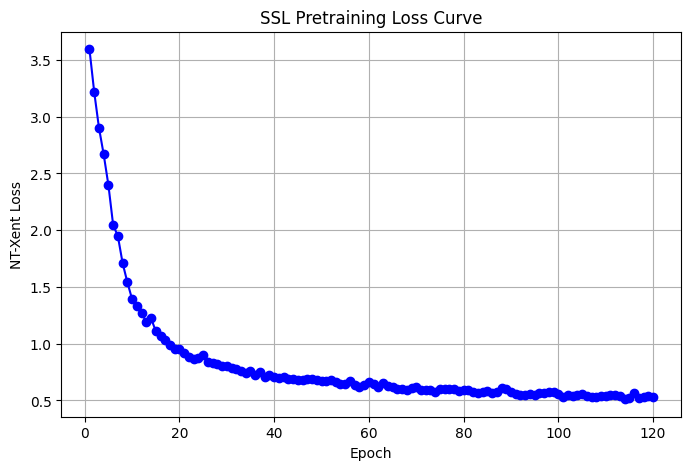

Saved frozen encoder: ./prdb_ssl/encoder_frozen_densenet121.pth


In [6]:


import os, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt


class CFG:
    OUT_DIR = "./prdb_ssl"
    IMG_SIZE = 224
    SSL_BATCH = 32
    SSL_EPOCHS = 120
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    HIDDEN_DIM = 512
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

os.makedirs(CFG.OUT_DIR, exist_ok=True)


def set_seed(seed=CFG.SEED):
    random.seed(seed)
    import numpy as np
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()
device = torch.device(CFG.DEVICE)
print("Using device:", device)


class SSLDataset(Dataset):
    """Return two augmented views of the same image"""
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.loc[idx, "image"]
        img = Image.open(img_path).convert("RGB")
        v1 = self.transform(img)
        v2 = self.transform(img)
        return v1, v2


def get_ssl_transform():
    return T.Compose([
        T.RandomResizedCrop(CFG.IMG_SIZE, scale=(0.6, 1.0)),
        T.RandomHorizontalFlip(),
        T.RandomRotation(10),
        T.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.02),
        T.RandomGrayscale(p=0.08),
        T.ToTensor(),
        T.GaussianBlur(kernel_size=9, sigma=(0.1,2.0)),
        T.RandomErasing(p=0.2, scale=(0.02,0.07), ratio=(0.3,3.3), value='random')
    ])

ssl_transform = get_ssl_transform()


#  DenseNet-121 + Projection Head

class DenseNet121WithProj(nn.Module):
    def __init__(self, proj_dim=CFG.PROJ_DIM, hidden_dim=CFG.HIDDEN_DIM, pretrained=False):
        super().__init__()
        self.backbone = models.densenet121(weights=None if not pretrained else models.DenseNet121_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()
        feat_dim = 1024
        self.proj_head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )

    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out,1)
        z = self.proj_head(out)
        return out, z

model = DenseNet121WithProj().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=CFG.SSL_LR, weight_decay=CFG.SSL_WEIGHT_DECAY)


#  NT-Xent Loss

def nt_xent_loss(z1, z2, temperature=CFG.TEMP):
    N = z1.size(0)
    z = torch.cat([z1, z2], dim=0)
    z = F.normalize(z, dim=1)
    sim = torch.matmul(z, z.T)
    exp_sim = torch.exp(sim / temperature)
    mask = (~torch.eye(2*N, dtype=torch.bool)).to(device)
    exp_sim = exp_sim * mask
    pos_sim = torch.cat([torch.diag(sim, N), torch.diag(sim, -N)], dim=0)
    numerator = torch.exp(pos_sim / temperature)
    denom = exp_sim.sum(dim=1)
    loss = -torch.log(numerator / denom)
    return loss.mean()


#  DataLoader

# Suppose your unlabeled_train_df is ready and has "image" column
unlabeled_dataset = SSLDataset(unlabeled_train_df, transform=ssl_transform)
ssl_loader = DataLoader(unlabeled_dataset, batch_size=CFG.SSL_BATCH, shuffle=True, num_workers=2)


#  SSL Training Loop + Loss History

best_loss = float('inf')
loss_history = []

for epoch in range(1, CFG.SSL_EPOCHS+1):
    model.train()
    epoch_loss = 0.0
    t0 = time.time()
    pbar = tqdm(ssl_loader, desc=f"Epoch {epoch}/{CFG.SSL_EPOCHS}", leave=False)
    
    for v1, v2 in pbar:
        v1, v2 = v1.to(device), v2.to(device)
        _, z1 = model(v1)
        _, z2 = model(v2)
        loss = nt_xent_loss(z1, z2)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    epoch_loss /= len(ssl_loader)
    loss_history.append(epoch_loss)
    t1 = time.time()
    print(f"Epoch {epoch:03d} avg_loss={epoch_loss:.4f} time={(t1-t0):.1f}s")
    
    # Save best model
    if epoch_loss < best_loss:
        best_loss = epoch_loss
        ckpt_path = os.path.join(CFG.OUT_DIR, "ssl_best_densenet121.pth")
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': epoch_loss
        }, ckpt_path)
        print(f"  -> New best saved: {ckpt_path}")


# Plot Loss Curve

plt.figure(figsize=(8,5))
plt.plot(range(1, CFG.SSL_EPOCHS+1), loss_history, marker='o', color='blue')
plt.title("SSL Pretraining Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("NT-Xent Loss")
plt.grid(True)
plt.show()


#  Freeze Encoder + Save

class EncoderOnly(nn.Module):
    def __init__(self, backbone_with_proj):
        super().__init__()
        self.encoder = backbone_with_proj.backbone
    def forward(self, x):
        features = self.encoder.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(features, (1,1))
        out = torch.flatten(out,1)
        return out

encoder_only = EncoderOnly(model).to(device)
for p in encoder_only.parameters():
    p.requires_grad = False

encoder_path = os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth")
torch.save(encoder_only.state_dict(), encoder_path)
print(f"Saved frozen encoder: {encoder_path}")


Extracting Features: 100%|██████████| 45/45 [00:17<00:00,  2.59it/s]


Feature shape: (1440, 1024)
Silhouette Score: 0.0391


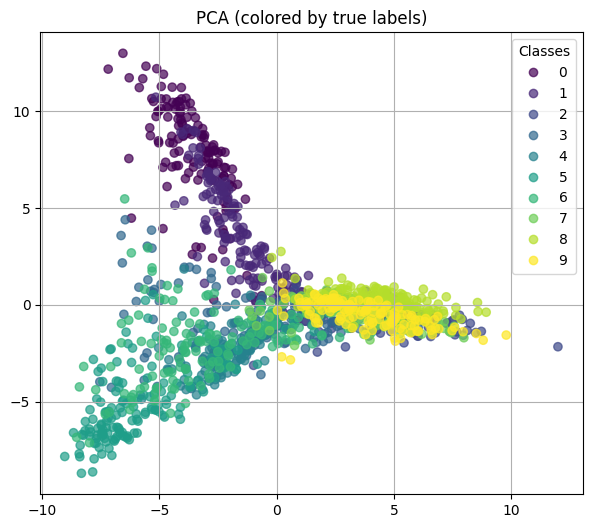

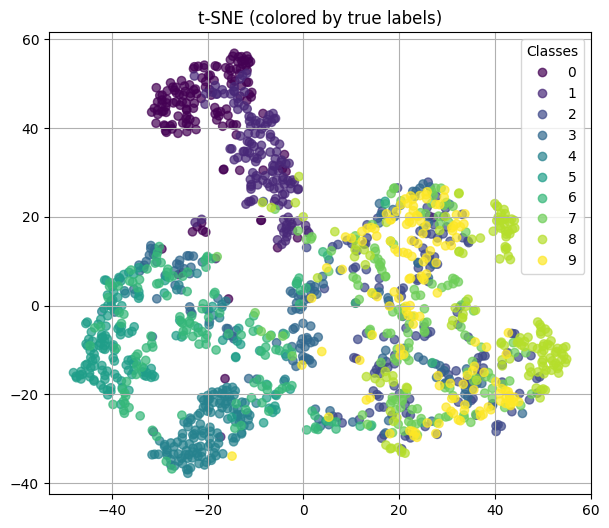

In [7]:

import numpy as np
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


# Build a dataset that returns (image, label)

class EvalDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        img = Image.open(self.df.loc[idx, "image"]).convert("RGB")
        label = self.df.loc[idx, "label"]
        return self.transform(img), label

eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

eval_dataset = EvalDataset(train_df, transform=eval_transform)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)


# Extract features using frozen encoder

encoder_only.eval()
all_feats = []
all_labels = []

with torch.no_grad():
    for imgs, labels in tqdm(eval_loader, desc="Extracting Features"):
        imgs = imgs.to(device)
        feats = encoder_only(imgs)          # (B, 1024)
        all_feats.append(feats.cpu().numpy())
        all_labels.extend(labels.numpy())

all_feats = np.concatenate(all_feats, axis=0)
all_labels = np.array(all_labels)

print("Feature shape:", all_feats.shape)


#  Silhouette Score

sil_score = silhouette_score(all_feats, all_labels)
print("Silhouette Score:", round(sil_score, 4))


# PCA Visualization (2D)

pca = PCA(n_components=2)
pca_feats = pca.fit_transform(all_feats)

plt.figure(figsize=(7,6))
scatter = plt.scatter(pca_feats[:,0], pca_feats[:,1], c=all_labels, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("PCA (colored by true labels)")
plt.grid(True)
plt.show()


# t-SNE Visualization (2D)

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, n_iter=1200)
tsne_feats = tsne.fit_transform(all_feats)

plt.figure(figsize=(7,6))
scatter = plt.scatter(tsne_feats[:,0], tsne_feats[:,1], c=all_labels, alpha=0.7)
plt.legend(*scatter.legend_elements(), title="Classes")
plt.title("t-SNE (colored by true labels)")
plt.grid(True)
plt.show()


In [17]:

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from tqdm import tqdm
import os


#  Config (reuse SSL CFG)

LP_BATCH = 32
LP_EPOCHS = 200
LP_LR = 1e-3
NUM_CLASSES = 10  # PRDB classes
device = torch.device(CFG.DEVICE)


# Data Transform (for Linear Probe)

lp_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_dataset = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/train"), transform=lp_transform)
val_dataset   = ImageFolder(root=os.path.join(CFG.OUT_DIR, "split_data/val"), transform=lp_transform)

train_loader = DataLoader(train_dataset, batch_size=LP_BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=LP_BATCH, shuffle=False, num_workers=2)

#  Linear Probe Model

class LinearProbe(nn.Module):
    def __init__(self, encoder, feat_dim=1024, num_classes=NUM_CLASSES):
        super().__init__()
        self.encoder = encoder
        for p in self.encoder.parameters():  # freeze encoder
            p.requires_grad = False
        self.classifier = nn.Linear(feat_dim, num_classes)

    def forward(self, x):
        with torch.no_grad():
            features = self.encoder(x)
        out = self.classifier(features)
        return out

# Load frozen encoder
encoder_only = EncoderOnly(model)
encoder_only.load_state_dict(torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth")))
encoder_only.to(device)
encoder_only.eval()

lp_model = LinearProbe(encoder_only).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(lp_model.classifier.parameters(), lr=LP_LR)


# Linear Probe Training Loop

best_val_acc = 0.0
for epoch in range(1, LP_EPOCHS+1):
    lp_model.train()
    train_loss = 0.0
    correct = 0
    total = 0
    pbar = tqdm(train_loader, desc=f"LP Epoch {epoch}/{LP_EPOCHS}", leave=False)
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = lp_model(imgs)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})
    
    train_loss /= total
    train_acc = correct / total
    print(f"Epoch {epoch} Train Loss={train_loss:.4f} Train Acc={train_acc:.4f}")
    
    # Validation
    lp_model.eval()
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = lp_model(imgs)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Val Acc={val_acc:.4f}")
    
    # Save best LP model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        lp_ckpt_path = os.path.join(CFG.OUT_DIR, "linear_probe_best.pth")
        torch.save(lp_model.state_dict(), lp_ckpt_path)
        print(f" -> New best Linear Probe saved: {lp_ckpt_path}")

print(f"Best Validation Accuracy: {best_val_acc:.4f}")

lp_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = lp_model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(CLASS_MAP.keys())))


Epoch 1 Train Loss=1.4249 Train Acc=0.5174


Epoch 1 Val Acc=0.6375
 -> New best Linear Probe saved: ./prdb_ssl/linear_probe_best.pth


Epoch 2 Train Loss=0.9915 Train Acc=0.6243


Epoch 2 Val Acc=0.6625
 -> New best Linear Probe saved: ./prdb_ssl/linear_probe_best.pth


Epoch 3 Train Loss=0.9012 Train Acc=0.6667


...

Epoch 198 Val Acc=0.7875


Epoch 199 Train Loss=0.3206 Train Acc=0.8868


Epoch 199 Val Acc=0.7750


Epoch 200 Train Loss=0.3288 Train Acc=0.8799


Epoch 200 Val Acc=0.7875
Best Validation Accuracy: 0.7875
[TEST] Accuracy: 0.8250
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      0.97      0.99        40
        Beroi       0.81      0.62      0.70        40
        BR-28       0.76      0.72      0.74        40
        BR-29       0.97      0.90      0.94        40
    Chinigura       0.91      1.00      0.95        40
    Ghee Bhog       0.76      0.80      0.78        40
 Katari Najir       0.59      0.68      0.63        40
Katari Siddho       0.81      0.75      0.78        40
      Miniket       0.95      0.97      0.96        40
       Swarna       0.73      0.82      0.78        40

     accuracy                           0.82       400
    macro avg       0.83      0.82      0.82       400
 weighted avg       0.83      0.82      0.82       400



In [21]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import os
from tqdm import tqdm

device = torch.device(CFG.DEVICE)

# Load SSL-trained encoder
encoder_only = EncoderOnly(model)  # same class from your code
encoder_only.load_state_dict(torch.load(
    os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth")
))
encoder_only.to(device)
encoder_only.eval()

for p in encoder_only.parameters():
    p.requires_grad = False

print("Frozen SSL encoder loaded!")



class MLPClassifier(nn.Module):
    def __init__(self, feat_dim=1024, hidden=512, classes=10):
        super().__init__()
        self.encoder = encoder_only   # frozen
        self.mlp = nn.Sequential(
            nn.Linear(feat_dim, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, classes)
        )

    def forward(self, x):
        with torch.no_grad():             
            feats = self.encoder(x)
        out = self.mlp(feats)              
        return out

num_classes = 10   # PRDB dataset
mlp_model = MLPClassifier(classes=num_classes).to(device)


eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_ds = ImageFolder("./prdb_ssl/split_data/train", transform=eval_transform)
val_ds   = ImageFolder("./prdb_ssl/split_data/val",   transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=2)



criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.mlp.parameters(), lr=1e-3)



best_acc = 0

for epoch in range(1, 201):
    mlp_model.train()
    total = 0
    correct = 0
    running_loss = 0

    pbar = tqdm(train_loader, desc=f"MLP Epoch {epoch}/200")

    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = mlp_model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch} Train Loss={train_loss:.4f}  Acc={train_acc:.4f}")

    # -------- Validation --------
    mlp_model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out = mlp_model(imgs)
            preds = out.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total
    print(f"Epoch {epoch} Val Acc={val_acc:.4f}")

    # Save best
    if val_acc > best_acc:
        best_acc = val_acc
        save_path = os.path.join(CFG.OUT_DIR, "best_mlp_classifier.pth")
        torch.save(mlp_model.state_dict(), save_path)
        print(f"  -> Best MLP Saved: {save_path}")

print("Best Validation Acc:", best_acc)


all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = mlp_model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=list(CLASS_MAP.keys())))


Frozen SSL encoder loaded!


MLP Epoch 1/200: 100%|██████████| 45/45 [00:08<00:00,  5.54it/s, loss=0.9635]

Epoch 1 Train Loss=1.2043  Acc=0.5576


Epoch 1 Val Acc=0.6625
  -> Best MLP Saved: ./prdb_ssl/best_mlp_classifier.pth


MLP Epoch 2/200: 100%|██████████| 45/45 [00:08<00:00,  5.53it/s, loss=1.1260]

...

Epoch 199 Train Loss=0.1580  Acc=0.9382


Epoch 199 Val Acc=0.7688


MLP Epoch 200/200: 100%|██████████| 45/45 [00:07<00:00,  5.90it/s, loss=0.2956]

Epoch 200 Train Loss=0.1189  Acc=0.9556


Epoch 200 Val Acc=0.7500
Best Validation Acc: 0.81875
[TEST] Accuracy: 0.8100
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      0.97      0.99        40
        Beroi       0.80      0.50      0.62        40
        BR-28       0.71      0.75      0.73        40
        BR-29       0.95      0.93      0.94        40
    Chinigura       0.97      0.97      0.97        40
    Ghee Bhog       0.76      0.78      0.77        40
 Katari Najir       0.60      0.72      0.66        40
Katari Siddho       0.75      0.75      0.75        40
      Miniket       0.90      0.95      0.93        40
       Swarna       0.70      0.78      0.74        40

     accuracy                           0.81       400
    macro avg       0.82      0.81      0.81       400
 weighted avg       0.82      0.81      0.81       400



In [22]:

from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Feature extraction function
def extract_features(loader, model, device):
    model.eval()
    feats_list, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = model(imgs)  # encoder returns features
            feats_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    feats_all = np.concatenate(feats_list, axis=0)
    labels_all = np.concatenate(labels_list, axis=0)
    return feats_all, labels_all

# Transform for Linear probe / SVM
svm_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

# Load datasets
train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=svm_transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"),   transform=svm_transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"),  transform=svm_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=False, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

encoder_only.eval()  # frozen encoder

X_train, y_train = extract_features(train_loader, encoder_only, device)
X_val, y_val     = extract_features(val_loader, encoder_only, device)
X_test, y_test   = extract_features(test_loader, encoder_only, device)

print("Feature shapes:", X_train.shape, X_val.shape, X_test.shape)


svm_clf = SVC(kernel='linear', C=1.0)
svm_clf.fit(X_train, y_train)


val_pred = svm_clf.predict(X_val)
val_acc = accuracy_score(y_val, val_pred)
print(f"[VAL] Accuracy: {val_acc:.4f}")


test_pred = svm_clf.predict(X_test)
test_acc = accuracy_score(y_test, test_pred)
print(f"[TEST] Accuracy: {test_acc:.4f}")

# Optional: Classification Report
CLASS_MAP = {cls: i for i, cls in enumerate(train_ds.classes)}
print("Classification Report:")
print(classification_report(y_test, test_pred, target_names=list(CLASS_MAP.keys())))


Feature shapes: (1440, 1024) (160, 1024) (400, 1024)
[VAL] Accuracy: 0.7937
[TEST] Accuracy: 0.7675
Classification Report:
               precision    recall  f1-score   support

         Aush       1.00      1.00      1.00        40
        BR-28       0.61      0.55      0.58        40
        BR-29       0.69      0.62      0.66        40
        Beroi       0.97      0.90      0.94        40
    Chinigura       0.91      0.97      0.94        40
    Ghee Bhog       0.71      0.75      0.73        40
 Katari Najir       0.52      0.62      0.57        40
Katari Siddho       0.70      0.65      0.68        40
      Miniket       0.93      0.95      0.94        40
       Swarna       0.65      0.65      0.65        40

     accuracy                           0.77       400
    macro avg       0.77      0.77      0.77       400
 weighted avg       0.77      0.77      0.77       400



In [24]:

#  Decision Tree 
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

# Suppose your train/val/test folders are same as before
from torchvision.datasets import ImageFolder


class CFG:
    SEED = 42
    OUT_DIR = "./prdb_ssl"
    IMG_SIZE = 224

# Feature extraction function
def extract_features(dataset, encoder, device):
    loader = DataLoader(dataset, batch_size=32, shuffle=False, num_workers=2)
    all_feats = []
    all_labels = []
    encoder.eval()
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            feats = encoder(imgs)
            all_feats.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())
    return np.vstack(all_feats), np.hstack(all_labels)

# Transforms
eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

# Datasets
train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=eval_transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=eval_transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=eval_transform)

# Extract features
print("Extracting train features...")
X_train, y_train = extract_features(train_ds, encoder_only, device)
print("Extracting val features...")
X_val, y_val = extract_features(val_ds, encoder_only, device)
print("Extracting test features...")
X_test, y_test = extract_features(test_ds, encoder_only, device)

# Combine train+val for final training
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.hstack([y_train, y_val])

# Train Decision Tree
dt_clf = DecisionTreeClassifier(max_depth=None, random_state=CFG.SEED)
dt_clf.fit(X_train_full, y_train_full)

# Evaluate on Test Set
y_pred = dt_clf.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")

# CLASS_MAP should match your folder order in ImageFolder
CLASS_MAP = {v: k for k, v in train_ds.class_to_idx.items()}  # idx->class name

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_MAP[i] for i in range(len(CLASS_MAP))]))


Extracting train features...
Extracting val features...
Extracting test features...
[TEST] Accuracy: 0.6650
Classification Report:
               precision    recall  f1-score   support

         Aush       0.90      0.93      0.91        40
        BR-28       0.47      0.42      0.45        40
        BR-29       0.50      0.55      0.52        40
        Beroi       0.94      0.75      0.83        40
    Chinigura       0.86      0.90      0.88        40
    Ghee Bhog       0.70      0.70      0.70        40
 Katari Najir       0.54      0.70      0.61        40
Katari Siddho       0.53      0.60      0.56        40
      Miniket       0.82      0.82      0.82        40
       Swarna       0.39      0.28      0.32        40

     accuracy                           0.67       400
    macro avg       0.67      0.67      0.66       400
 weighted avg       0.67      0.67      0.66       400



In [32]:
import os
import torch
from torch.utils.data import DataLoader
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np


class CFG:
    OUT_DIR = "./prdb_ssl"
    IMG_SIZE = 224
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

device = torch.device(CFG.DEVICE)

# EncoderOnly should be defined as in your SSL code
encoder_only = EncoderOnly(model)
encoder_only.load_state_dict(
    torch.load(os.path.join(CFG.OUT_DIR, "encoder_frozen_densenet121.pth"))
)
encoder_only.to(device)
encoder_only.eval()

for p in encoder_only.parameters():
    p.requires_grad = False

print("Frozen SSL encoder loaded!")

eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=eval_transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"), transform=eval_transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"), transform=eval_transform)

# CLASS_MAP strings for report
CLASS_MAP = {i: c for i, c in enumerate(train_ds.classes)}
target_names = [str(CLASS_MAP[i]) for i in range(len(CLASS_MAP))]


def extract_features(dataset, encoder, batch_size=32):
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=2)
    features_list, labels_list = [], []
    encoder.eval()
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc="Extracting features"):
            imgs = imgs.to(device)
            feats = encoder(imgs)
            features_list.append(feats.cpu().numpy())
            labels_list.append(labels.numpy())
    features = np.concatenate(features_list, axis=0)
    labels = np.concatenate(labels_list, axis=0)
    return features, labels

X_train, y_train = extract_features(train_ds, encoder_only)
X_val, y_val     = extract_features(val_ds, encoder_only)
X_test, y_test   = extract_features(test_ds, encoder_only)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_train)


y_pred = rf_clf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))


Frozen SSL encoder loaded!


Extracting features: 100%|██████████| 13/13 [00:02<00:00,  5.95it/s]


[TEST] Accuracy: 0.8050
Classification Report:
               precision    recall  f1-score   support

         Aush       0.97      0.97      0.97        40
        BR-28       0.77      0.68      0.72        40
        BR-29       0.72      0.70      0.71        40
        Beroi       0.97      0.90      0.94        40
    Chinigura       0.89      0.97      0.93        40
    Ghee Bhog       0.79      0.78      0.78        40
 Katari Najir       0.58      0.78      0.67        40
Katari Siddho       0.74      0.65      0.69        40
      Miniket       0.95      0.93      0.94        40
       Swarna       0.72      0.70      0.71        40

     accuracy                           0.81       400
    macro avg       0.81      0.80      0.81       400
 weighted avg       0.81      0.81      0.81       400



In [37]:

import os, random, time
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models
from torchvision.datasets import ImageFolder
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report




class CFG:
    OUT_DIR = "./prdb_ssl"
    IMG_SIZE = 224
    SSL_BATCH = 32
    SSL_EPOCHS = 120
    SSL_LR = 3e-4
    SSL_WEIGHT_DECAY = 1e-4
    TEMP = 0.2
    PROJ_DIM = 128
    HIDDEN_DIM = 512
    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    FT_EPOCHS = 150
    FT_LR = 1e-3
    NUM_CLASSES = 10  # PRDB dataset

os.makedirs(CFG.OUT_DIR, exist_ok=True)
device = torch.device(CFG.DEVICE)


# Seed

def set_seed(seed=CFG.SEED):
    random.seed(seed)
    import numpy as np
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
set_seed()


# Encoder Only Class

class EncoderOnly(nn.Module):
    def __init__(self, backbone_with_proj):
        super().__init__()
        self.encoder = backbone_with_proj.backbone
    def forward(self, x):
        features = self.encoder.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out,1)
        return out


#  DenseNet + Projection Head

class DenseNet121WithProj(nn.Module):
    def __init__(self, proj_dim=CFG.PROJ_DIM, hidden_dim=CFG.HIDDEN_DIM, pretrained=False):
        super().__init__()
        self.backbone = models.densenet121(weights=None if not pretrained else models.DenseNet121_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()
        feat_dim = 1024
        self.proj_head = nn.Sequential(
            nn.Linear(feat_dim, hidden_dim),
            nn.ReLU(inplace=True),
            nn.Linear(hidden_dim, proj_dim)
        )
    def forward(self, x):
        features = self.backbone.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out,1)
        z = self.proj_head(out)
        return out, z


# Load SSL Pretrained Encoder

encoder = DenseNet121WithProj(proj_dim=CFG.PROJ_DIM, hidden_dim=CFG.HIDDEN_DIM)
ssl_ckpt = torch.load(os.path.join(CFG.OUT_DIR, "ssl_best_densenet121.pth"), map_location=device)
encoder.load_state_dict(ssl_ckpt['model_state_dict'])
encoder.to(device)


# Full Fine-Tune Model

class FineTuneModel(nn.Module):
    def __init__(self, encoder, num_classes=CFG.NUM_CLASSES):
        super().__init__()
        self.encoder = encoder.backbone  # full backbone fine-tune
        self.classifier = nn.Linear(1024, num_classes)
    def forward(self, x):
        features = self.encoder.features(x)
        out = F.relu(features, inplace=True)
        out = F.adaptive_avg_pool2d(out, (1,1))
        out = torch.flatten(out,1)
        out = self.classifier(out)
        return out

ft_model = FineTuneModel(encoder).to(device)


# Data Loaders

transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor()
])

train_ds = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/train"), transform=transform)
val_ds   = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/val"),   transform=transform)
test_ds  = ImageFolder(os.path.join(CFG.OUT_DIR, "split_data/test"),  transform=transform)

train_loader = DataLoader(train_ds, batch_size=CFG.SSL_BATCH, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_ds,   batch_size=CFG.SSL_BATCH, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=CFG.SSL_BATCH, shuffle=False, num_workers=2)


# Optimizer + Loss

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(ft_model.parameters(), lr=CFG.FT_LR)


# Training Loop

best_val_acc = 0.0

for epoch in range(1, CFG.FT_EPOCHS+1):
    ft_model.train()
    total, correct, running_loss = 0, 0, 0
    pbar = tqdm(train_loader, desc=f"FT Epoch {epoch}/{CFG.FT_EPOCHS}")
    
    for imgs, labels in pbar:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = ft_model(imgs)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({'loss': f"{loss.item():.4f}"})

    train_loss = running_loss / total
    train_acc = correct / total
    print(f"Epoch {epoch} Train Loss={train_loss:.4f} Acc={train_acc:.4f}")

    # Validation
    ft_model.eval()
    val_correct, val_total = 0,0
    with torch.no_grad():
        for imgs, labels in val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = ft_model(imgs)
            preds = outputs.argmax(dim=1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)
    val_acc = val_correct / val_total
    print(f"Epoch {epoch} Val Acc={val_acc:.4f}")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_path = os.path.join(CFG.OUT_DIR, "fine_tuned_encoder.pth")
        torch.save(ft_model.state_dict(), save_path)
        print(f"  -> New Best Fine-Tuned Model Saved: {save_path}")

print("Best Validation Accuracy:", best_val_acc)


# Test Evaluation

ft_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        outputs = ft_model(imgs)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
print(f"[TEST] Accuracy: {acc:.4f}")
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=[c[0] for c in test_ds.classes]))


FT Epoch 1/150: 100%|██████████| 45/45 [00:08<00:00,  5.04it/s, loss=0.6108]

Epoch 1 Train Loss=0.9532 Acc=0.6729


Epoch 1 Val Acc=0.3187
  -> New Best Fine-Tuned Model Saved: ./prdb_ssl/fine_tuned_encoder.pth


FT Epoch 2/150: 100%|██████████| 45/45 [00:08<00:00,  5.04it/s, loss=0.3182]

Epoch 2 Train Loss=0.5527 Acc=0.8104


...

Epoch 149 Train Loss=0.0005 Acc=1.0000


Epoch 149 Val Acc=0.9500


FT Epoch 150/150: 100%|██████████| 45/45 [00:09<00:00,  4.99it/s, loss=0.0002]

Epoch 150 Train Loss=0.0036 Acc=0.9993


Epoch 150 Val Acc=0.9187
Best Validation Accuracy: 0.9625
[TEST] Accuracy: 0.9200
Classification Report:
              precision    recall  f1-score   support

           A       1.00      1.00      1.00        40
           B       0.87      0.85      0.86        40
           B       0.97      0.93      0.95        40
           B       0.98      1.00      0.99        40
           C       0.98      1.00      0.99        40
           G       0.79      0.85      0.82        40
           K       0.97      0.72      0.83        40
           K       0.80      0.97      0.88        40
           M       0.97      0.97      0.97        40
           S       0.92      0.90      0.91        40

    accuracy                           0.92       400
   macro avg       0.92      0.92      0.92       400
weighted avg       0.92      0.92      0.92       400

